# Análise Tática: A Metamorfose do Manchester City (2019/2020 e 2020/2021)
#### **Do Ataque Tradicional ao Sistema de Falso 9**

## Installation and download of requirements

In [ ]:
!pip install soccerdata pandas matplotlib mplsoccer

In [9]:
!pip install rpy2

In [ ]:
# 1. Download the Chrome installer
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb

# 2. Run the installer (this will show some dependency errors, which is normal)
!dpkg -i google-chrome-stable_current_amd64.deb

# 3. Force install the missing dependencies
!apt-get install -f -y

--2026-05-31 13:29:26--  https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
Resolving dl.google.com (dl.google.com)... 64.233.170.190, 64.233.170.91, 64.233.170.93, ...
Connecting to dl.google.com (dl.google.com)|64.233.170.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 129833324 (124M) [application/x-debian-package]
Saving to: ‘google-chrome-stable_current_amd64.deb.1’

google-chrome-stabl 100%[===================>] 123.82M   263MB/s    in 0.5s    

2026-05-31 13:29:27 (263 MB/s) - ‘google-chrome-stable_current_amd64.deb.1’ saved [129833324/129833324]

(Reading database ... 118669 files and directories currently installed.)
Preparing to unpack google-chrome-stable_current_amd64.deb ...
Unpacking google-chrome-stable (148.0.7778.215-1) over (148.0.7778.215-1) ...
Setting up google-chrome-stable (148.0.7778.215-1) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...
Processing triggers for man-db (2.10.2-1) ...
Reading package 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
import soccerdata as sd
from google.colab import files

[05/31/2026 01:33:04 PM] INFO     No custom team name replacements found. You can configure these in  ]8;id=12679402;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=12679403;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_config.py#92\92]8;;\
                                  /root/soccerdata/config/teamname_replacements.json.                              

                         INFO     No custom league dict found. You can configure additional leagues  ]8;id=12679409;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=12679410;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_config.py#190\190]8;;\
                                  in /root/soccerdata/config/league_dict.json.                                     

In [1]:
%load_ext rpy2.ipython

In [3]:
%%R
install.packages("devtools", quiet=TRUE)
devtools::install_github("JaseZiv/worldfootballR", quiet=TRUE)
library(worldfootballR)

ℹ The package "remotes" is required.
✖ Would you like to install it?

1: Yes
2: No

Selection: 1

 Found  1  deps for  0/1  pkgs [⠋] Resolving standard (CRAN/BioC) packages
 Found  1  deps for  0/1  pkgs [⠙] Resolving standard (CRAN/BioC) packages
Checking for 8 new metadata files
 Found  1  deps for  0/1  pkgs [⠹] Resolving standard (CRAN/BioC) packages
⠋ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠸] Resolving standard (CRAN/BioC) packages
 Found  1  deps for  0/1  pkgs [⠼] Resolving standard (CRAN/BioC) packages
⠙ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠴] Resolving standard (CRAN/BioC) packages
⠹ Updating metadata database [0/8] | Downloading [2.01 kB / 2.01 kB]
 Found  1  deps for  0/1  pkgs [⠦] Resolving standard (CRAN/BioC) packages
⠸ Updating metadata database [0/8] | Downloading [325.32 kB / 3.58 MB]
 Found  1  deps for  0/1  pkgs [⠧] Resolving standard (CRAN/BioC) packages
⠼ Upda

Installing 3 packages: snakecase, qdapRegex, janitor
In addition: Warning message:
`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


## Data

### Util functions

In [120]:
def imprimir_descricoes(df, descriptions, nome_tabela="Tabela"):
    print(f"--- COLUNAS DA TABELA: {nome_tabela.upper()} ---\n")

    # Tratamento para colunas não encontradas ignorarem espaços/símbolos se necessário
    for col in df.columns:
        # Tenta buscar a coluna exatamente como está. Se não achar, usa um aviso padrão
        if descriptions == descricoes_understat:
            descricao = descricoes_understat.get(col, "Descrição não mapeada (métrica muito específica).")
        else:
            descricao = descricoes_fbref.get(col, "Descrição não mapeada (métrica muito específica).")
        print(f"[{col}] : {descricao}")

    print("\n" + "="*70 + "\n")


### World Football R Data

#### FBref -- Outfield Player Stats
* **"standard"**: The core metrics (goals, assists, expected goals/assists, cards,
and basic playing time).

* **"shooting"**: Detailed finalization data (shots, shots on target, average distance, and xG per shot).

* **"passing"**: Pass completion rates by distance (short, medium, long), key passes, and progressive passes.

* **"passing_types"**: Specifics on how passes were made (live-ball, dead-ball, passes under pressure, crosses, switches).

* **"defense"**: Defensive actions by pitch zone (tackles, interceptions, blocks, clearances, and success rates against dribblers).

* **"possession"**: Ball control metrics (touches in specific thirds, successful dribbles, progressive carries, miscontrols, and times dispossessed).

* **"playing_time"**: Deep dive into minutes (starts, substitutions, bench time, and team plus/minus while the player is on the pitch).

* **"misc"**: Miscellaneous actions (fouls committed/drawn, offsides, aerial duels won/lost, ball recoveries).

##### Columns' descriptions

In [100]:
descricoes_fbref = {
    # ==========================================
    # 0. INFORMAÇÕES BÁSICAS (Comum a todas as tabelas)
    # ==========================================
    "Season_End_Year": "Ano de término da temporada (Ex: 2020 para 19/20)",
    "Player": "Nome do jogador",
    "Nation": "Nacionalidade do jogador",
    "Pos": "Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)",
    "Squad": "Equipe/Time",
    "Comp": "Competição (Ex: Premier League)",
    "Age": "Idade do jogador",
    "Born": "Ano de nascimento",
    "Url": "Link para o perfil do jogador no FBref",
    "Mins_Per_90": "Minutos totais jogados divididos por 90",
    "MP_Playing": "Partidas em que entrou em campo",
    "Starts_Playing": "Partidas em que começou como titular",
    "Min_Playing": "Total de minutos jogados",
    "Mins_Per_90_Playing": "Minutos jogados divididos por 90 (equivalente a jogos completos)",

    # ==========================================
    # 1. STANDARD STATS & PROGRESSÃO
    # ==========================================
    "Gls": "Gols marcados",
    "Ast": "Assistências para gol",
    "G+A": "Gols + Assistências",
    "G_minus_PK": "Gols marcados (excluindo pênaltis)",
    "PK": "Pênaltis convertidos",
    "PKatt": "Pênaltis cobrados",
    "Gls_Per": "Gols marcados a cada 90 minutos",
    "Ast_Per": "Assistências a cada 90 minutos",
    "G+A_Per": "Gols e Assistências a cada 90 minutos",
    "G_minus_PK_Per": "Gols sem pênalti a cada 90 min",
    "G+A_minus_PK_Per": "Gols e Assistências sem pênalti a cada 90 min",
    "xG_Expected": "Expected Goals (Gols Esperados)",
    "npxG_Expected": "Non-Penalty xG (Gols Esperados sem pênalti)",
    "xAG_Expected": "Expected Assisted Goals (Assistências Esperadas)",
    "npxG+xAG_Expected": "Soma de npxG e xAG",
    "xG_Per": "Gols Esperados a cada 90 minutos",
    "xAG_Per": "Assistências Esperadas a cada 90 minutos",
    "xG+xAG_Per": "Gols + Assistências Esperadas a cada 90 minutos",
    "npxG_Per": "Gols Esperados sem pênalti a cada 90 minutos",
    "npxG+xAG_Per": "Gols Esperados sem pênalti + Assistências Esperadas a cada 90 min",
    "xAG": "Expected Assisted Goals (Assistências Esperadas baseadas no chute)",
    "xA_Expected": "xA - Assistências Esperadas (métrica clássica)",
    "A_minus_xA": "Assistências reais menos xA (Positivo = Mais assistências que o esperado)",
    "A_minus_xAG": "Assistências reais menos xAG",
    "A_minus_xAG_Expected": "Assistências reais menos xAG",
    "PrgC_Progression": "Progressive Carries - Conduções progressivas",
    "PrgP_Progression": "Progressive Passes - Passes progressivos realizados",
    "PrgR_Progression": "Progressive Passes Received - Passes progressivos recebidos",
    "Prog": "Ações progressivas (Passes ou Conduções, dependendo da tabela)",

    # ==========================================
    # 2. SHOOTING STATS (Finalizações)
    # ==========================================
    "Gls_Standard": "Gols marcados (Total)",
    "Sh_Standard": "Total de finalizações tentadas",
    "SoT_Standard": "Finalizações no alvo",
    "SoT_percent_Standard": "Porcentagem de finalizações no alvo",
    "Sh_per_90_Standard": "Finalizações a cada 90 minutos",
    "SoT_per_90_Standard": "Finalizações no alvo a cada 90 min",
    "G_per_Sh_Standard": "Gols por finalização (Taxa de conversão)",
    "G_per_SoT_Standard": "Gols por finalização no alvo",
    "Dist_Standard": "Distância média das finalizações (em jardas)",
    "FK_Standard": "Finalizações de falta direta",
    "PK_Standard": "Pênaltis convertidos",
    "PKatt_Standard": "Pênaltis cobrados",
    "npxG_per_Sh_Expected": "Qualidade média de cada chute (npxG / chutes)",
    "G_minus_xG_Expected": "Gols reais menos Gols Esperados (Desempenho de finalização)",
    "np:G_minus_xG_Expected": "Gols reais sem pênalti menos npxG",

    # ==========================================
    # 3. PASSING STATS (Passes)
    # ==========================================
    "Cmp_Total": "Passes completos (Total)",
    "Att_Total": "Passes tentados (Total)",
    "Cmp_percent_Total": "Porcentagem de acerto de passes (Total)",
    "TotDist_Total": "Distância total de passes completos (jardas)",
    "PrgDist_Total": "Distância progressiva total de passes (jardas)",
    "Cmp_Short": "Passes curtos completos (5-15 jardas)",
    "Att_Short": "Passes curtos tentados",
    "Cmp_percent_Short": "Acerto de passes curtos",
    "Cmp_Medium": "Passes médios completos (15-30 jardas)",
    "Att_Medium": "Passes médios tentados",
    "Cmp_percent_Medium": "Acerto de passes médios",
    "Cmp_Long": "Passes longos completos (30+ jardas)",
    "Att_Long": "Passes longos tentados",
    "Cmp_percent_Long": "Acerto de passes longos",
    "xA": "xA Histórico (Métrica antiga de assistências esperadas)",
    "KP": "Key Passes - Passes que resultam diretamente em finalização",
    "PrgP": "Progressive Passes - Passes progressivos",
    "1_slash_3": "Passes completados no terço final (terço de ataque)",
    "Final_Third": "Passes completados para o terço final do campo (Ataque)",
    "PPA": "Passes completados para dentro da grande área",
    "CrsPA": "Cruzamentos completados para a grande área",

    # ==========================================
    # 4. PASSING TYPES (Tipos de Passe)
    # ==========================================
    "Live_Pass_Types": "Passes com a bola rolando",
    "Dead_Pass_Types": "Passes de bola parada (faltas, escanteios)",
    "FK_Pass_Types": "Passes de cobrança de falta",
    "TB_Pass_Types": "Through Balls - Passes em profundidade rasgando a defesa",
    "Sw_Pass_Types": "Switches - Inversões de jogo (passes longos laterais)",
    "Crs_Pass_Types": "Cruzamentos tentados",
    "TI_Pass_Types": "Cobranças de lateral",
    "CK_Pass_Types": "Cobranças de escanteio",
    "In_Corner_Kicks": "Escanteios cobrados fechados (curvando para o gol)",
    "Out_Corner_Kicks": "Escanteios cobrados abertos (curvando para fora)",
    "Str_Corner_Kicks": "Escanteios cobrados retos",
    "Cmp_Outcomes": "Passes completados (Resultado)",
    "Off_Outcomes": "Passes que resultaram em impedimento",
    "Blocks_Outcomes": "Passes bloqueados pelo adversário",
    "Att": "Passes tentados (Total)",
    "Live_Pass": "Passes com a bola rolando",
    "Dead_Pass": "Passes de bola parada (faltas, escanteios, etc.)",
    "FK_Pass": "Passes de cobrança de falta",
    "TB_Pass": "Through Balls - Passes em profundidade rasgando a defesa",
    "Sw_Pass": "Switches - Inversões de jogo (passes longos laterais)",
    "Crs_Pass": "Cruzamentos tentados",
    "TI_Pass": "Cobranças de lateral",
    "CK_Pass": "Cobranças de escanteio",
    "In_Corner": "Escanteios cobrados fechados (curvando para o gol)",
    "Out_Corner": "Escanteios cobrados abertos (curvando para fora)",
    "Str_Corner": "Escanteios cobrados retos",

    # ==========================================
    # 5. DEFENSE (Defesa)
    # ==========================================
    "Tkl_Tackles": "Tackles - Desarmes totais",
    "TklW_Tackles": "Desarmes ganhos (O time recuperou a posse de bola)",
    "Def_3rd_Tackles": "Desarmes realizados no terço defensivo",
    "Def 3rd_Tackles": "Desarmes realizados no terço defensivo",
    "Mid_3rd_Tackles": "Desarmes realizados no terço central",
    "Mid 3rd_Tackles": "Desarmes realizados no terço central",
    "Att_3rd_Tackles": "Desarmes realizados no terço de ataque",
    "Att 3rd_Tackles": "Desarmes realizados no terço de ataque",
    "Tkl_Challenges": "Dribladores desarmados com sucesso",
    "Att_Challenges": "Dribladores enfrentados",
    "Tkl_percent_Challenges": "Porcentagem de sucesso contra dribladores",
    "Lost_Challenges": "Duelos perdidos para um driblador",
    "Blocks_Blocks": "Total de bloqueios",
    "Sh_Blocks": "Chutes adversários bloqueados",
    "Pass_Blocks": "Passes adversários bloqueados",
    "Int": "Interceptações de passe",
    "Tkl_plus_Int": "Soma de Desarmes e Interceptações",
    "Tkl+Int": "Soma de Desarmes (Tackles) e Interceptações",
    "Clr": "Clearances - Cortes ou afastamentos da área de perigo",
    "Err": "Erros individuais que resultaram em finalização do adversário",

    # ==========================================
    # 6. POSSESSION (Posse de Bola)
    # ==========================================
    "Touches_Touches": "Total de toques na bola",
    "Def_Pen_Touches": "Toques dentro da própria área de pênalti",
    "Def Pen_Touches": "Toques dentro da própria área de pênalti",
    "Def_3rd_Touches": "Toques no terço defensivo",
    "Def 3rd_Touches": "Toques no terço defensivo",
    "Mid_3rd_Touches": "Toques no terço central",
    "Mid 3rd_Touches": "Toques no terço central",
    "Att_3rd_Touches": "Toques no terço de ataque",
    "Att 3rd_Touches": "Toques no terço de ataque",
    "Att_Pen_Touches": "Toques dentro da área adversária",
    "Att Pen_Touches": "Toques dentro da área adversária",
    "Live_Touches": "Toques com a bola rolando",
    "Att_Take_Ons": "Tentativas de drible (Take-ons)",
    "Att_Take": "Tentativas de drible (Take-ons)",
    "Succ_Take_Ons": "Dribles bem-sucedidos",
    "Succ_Take": "Dribles bem-sucedidos",
    "Succ_percent_Take_Ons": "Porcentagem de sucesso nos dribles",
    "Succ_percent_Take": "Porcentagem de sucesso nos dribles",
    "Tkld_Take_Ons": "Vezes desarmado ao tentar driblar",
    "Tkld_Take": "Vezes desarmado ao tentar driblar",
    "Tkld_percent_Take_Ons": "Porcentagem de vezes desarmado",
    "Tkld_percent_Take": "Porcentagem de vezes que foi desarmado ao driblar",
    "Carries_Carries": "Conduções de bola (Controle com a bola no pé)",
    "TotDist_Carries": "Distância total conduzindo a bola (jardas)",
    "PrgDist_Carries": "Distância progressiva conduzindo a bola (jardas)",
    "PrgC_Carries": "Conduções progressivas",
    "1_slash_3_Carries": "Conduções para o terço final do campo",
    "Final_Third_Carries": "Conduções de bola para o terço final do campo",
    "CPA_Carries": "Conduções para dentro da grande área",
    "Mis_Carries": "Miscontrols - Domínios de bola incompletos/perdidos",
    "Dis_Carries": "Dispossessed - Desarmes sofridos sem tentar um drible",
    "Rec_Receiving": "Passes recebidos com sucesso",
    "PrgR_Receiving": "Passes progressivos recebidos",

    # ==========================================
    # 7. PLAYING TIME STATS (Tempo de Jogo)
    # ==========================================
    "MP_Playing.Time": "Partidas jogadas",
    "Min_Playing.Time": "Minutos totais jogados",
    "Mn_per_MP_Playing.Time": "Média de minutos jogados por partida",
    "Min_percent_Playing.Time": "Porcentagem dos minutos totais do time jogados",
    "Mins_Per_90_Playing.Time": "Minutos divididos por 90",
    "Starts_Starts": "Jogos iniciados como titular",
    "Mn_per_Start_Starts": "Minutos médios jogados quando titular",
    "Compl_Starts": "Jogos como titular em que não foi substituído",
    "Subs_Subs": "Vezes que entrou como substituto",
    "Mn_per_Sub_Subs": "Média de minutos jogados como substituto",
    "unSub_Subs": "Jogos no banco sem entrar em campo",
    "PPM_Team.Success": "Pontos conquistados por jogo pelo time com ele em campo",
    "onG_Team.Success": "Gols a favor com o jogador em campo",
    "onGA_Team.Success": "Gols sofridos com o jogador em campo",
    "plus_per__minus__Team.Success": "Saldo de gols com o jogador em campo",
    "plus_per__minus_90_Team.Success": "Saldo de gols por 90 min com ele em campo",
    "On_minus_Off_Team.Success": "Diferença no saldo de gols (Com ele vs Sem ele)",
    "onxG_Team.Success..xG.": "xG a favor com o jogador em campo",
    "onxGA_Team.Success..xG": "xG contra com o jogador em campo",
    "xGplus_per__minus__Team.Success..xG": "Saldo de xG com o jogador em campo",
    "xGplus_per__minus_90_Team.Success..xG": "Saldo de xG do time a cada 90 minutos com o jogador em campo",
    "On_minus_Off_Team.Success..xG": "Diferença do saldo de xG (Com o jogador em campo vs. Fora de campo)",

    # ==========================================
    # 8. MISC STATS (Estatísticas Diversas)
    # ==========================================
    "CrdY": "Cartões amarelos",
    "CrdR": "Cartões vermelhos",
    "2CrdY": "Expulsões por segundo cartão amarelo",
    "Fls": "Faltas cometidas",
    "Fld": "Faltas sofridas",
    "Off": "Impedimentos",
    "Crs": "Cruzamentos totais",
    "TklW": "Desarmes com recuperação de bola",
    "PKwon": "Pênaltis sofridos a favor do time",
    "PKcon": "Pênaltis cometidos contra o time",
    "OG": "Gols contra marcados",
    "Recov": "Recuperações de bolas soltas",
    "Won_Aerial": "Duelos aéreos ganhos",
    "Lost_Aerial": "Duelos aéreos perdidos",
    "Won_percent_Aerial": "Porcentagem de vitória em duelos aéreos"
}

#### Pulled data from worldfootballr

In [125]:
%%R -o standard_stats -o shooting_stats -o passing_stats -o passing_types_stats -o playing_time_stats -o defense_stats -o possession_stats -o misc_stats

# Define the seasons (2020 = 2019/2020, 2021 = 2020/2021)
seasons <- c(2020, 2021)

# Create directory if it doesn't exist
dir.create("/root/soccerdata/data/FBref/", showWarnings = FALSE)

# Standard Stats
standard_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "standard", team_or_player = "player")
standard_stats <- standard_all[standard_all$Comp == "Premier League", ]
write.csv(standard_stats, "/root/soccerdata/data/FBref/standard_stats.csv", row.names = FALSE)

# Shooting Stats
shooting_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "shooting", team_or_player = "player")
shooting_stats <- shooting_all[shooting_all$Comp == "Premier League", ]
write.csv(shooting_stats, "/root/soccerdata/data/FBref/shooting_stats.csv", row.names = FALSE)

# Passing Stats
passing_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "passing", team_or_player = "player")
passing_stats <- passing_all[passing_all$Comp == "Premier League", ]
write.csv(passing_stats, "/root/soccerdata/data/FBref/passing_stats.csv", row.names = FALSE)

# Passing-Types Stats
passing_types_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "passing_types", team_or_player = "player")
passing_types_stats <- passing_types_all[passing_types_all$Comp == "Premier League", ]
write.csv(passing_types_stats, "/root/soccerdata/data/FBref/passing_types_stats.csv", row.names = FALSE)

# Defense Stats
defense_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "defense", team_or_player = "player")
defense_stats <- defense_all[defense_all$Comp == "Premier League", ]
write.csv(defense_stats, "/root/soccerdata/data/FBref/defense_stats.csv", row.names = FALSE)

# Possession Stats
possession_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "possession", team_or_player = "player")
possession_stats <- possession_all[possession_all$Comp == "Premier League", ]
write.csv(possession_stats, "/root/soccerdata/data/FBref/possession_stats.csv", row.names = FALSE)

# Playing Time Stats
playing_time_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "playing_time", team_or_player = "player")
playing_time_stats <- playing_time_all[playing_time_all$Comp == "Premier League", ]
write.csv(playing_time_stats, "/root/soccerdata/data/FBref/playing_time_stats.csv", row.names = FALSE)

# Misc Stats
misc_all <- load_fb_big5_advanced_season_stats(season_end_year = seasons, stat_type = "misc", team_or_player = "player")
misc_stats <- misc_all[misc_all$Comp == "Premier League", ]
write.csv(misc_stats, "/root/soccerdata/data/FBref/misc_stats.csv", row.names = FALSE)

→ Data last updated 2025-09-18 17:39:32.777853012085 UTC
→ Data last updated 2025-09-18 17:40:11.6921770572662 UTC
→ Data last updated 2025-09-18 17:40:22.6840300559998 UTC
→ Data last updated 2025-09-18 17:40:33.5254199504852 UTC
→ Data last updated 2024-10-17 17:40:47.4434180259705 UTC
→ Data last updated 2024-10-17 17:41:09.19123697280884 UTC
→ Data last updated 2025-09-18 17:39:52.8585760593414 UTC
→ Data last updated 2024-10-17 17:41:19.1918120384216 UTC


#### Display dataframes

In [91]:
# Filter the newly loaded standard_stats for Manchester City
mancity_standard = standard_stats[standard_stats['Squad'] == 'Manchester City']
imprimir_descricoes(standard_stats, "Standard Stats")
mancity_standard.head()

--- COLUNAS DA TABELA: STANDARD STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[MP_Playing] : Partidas em que entrou em campo
[Starts_Playing] : Partidas em que começou como titular
[Min_Playing] : Total de minutos jogados
[Mins_Per_90_Playing] : Minutos jogados divididos por 90 (equivalente a jogos completos)
[Gls] : Gols marcados
[Ast] : Assistências para gol
[G+A] : Gols + Assistências
[G_minus_PK] : Gols marcados (excluindo pênaltis)
[PK] : Pênaltis convertidos
[PKatt] : Pênaltis cobrados
[CrdY] : Cartões amarelos
[CrdR] : Cartões vermelhos
[PrgC_Progression] : Progressive Carries - Conduções progressivas
[PrgP_Progression] : Progressive Passes - Passes progressivos realizados
[PrgR_Progression] : Progressive P

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,MP_Playing,Starts_Playing,...,xG_Expected,npxG_Expected,xAG_Expected,npxG+xAG_Expected,xG_Per,xAG_Per,xG+xAG_Per,npxG_Per,npxG+xAG_Per,Url
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,24.0,18.0,...,14.5,12.1,2.3,14.4,0.90,0.14,1.04,0.75,0.89,https://fbref.com/en/players/4d034881/Sergio-A...
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,6.0,4.0,...,0.2,0.2,1.5,1.7,0.05,0.32,0.36,0.05,0.36,https://fbref.com/en/players/30941e96/Angelino
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,4.0,3.0,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,https://fbref.com/en/players/10072610/Claudio-...
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,17.0,13.0,...,0.6,0.6,2.8,3.3,0.04,0.21,0.25,0.04,0.25,https://fbref.com/en/players/bd6351cd/Joao-Can...
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,35.0,32.0,...,7.3,5.8,20.0,25.8,0.24,0.65,0.88,0.19,0.83,https://fbref.com/en/players/e46012d4/Kevin-De...


In [92]:
# Filter the newly loaded shooting_stats for Manchester City
mancity_shooting = shooting_stats[shooting_stats['Squad'] == 'Manchester City']
imprimir_descricoes(shooting_stats, "Shooting Stats")
mancity_shooting.head()

--- COLUNAS DA TABELA: SHOOTING STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[Mins_Per_90] : Minutos totais jogados divididos por 90
[Gls_Standard] : Gols marcados (Total)
[Sh_Standard] : Total de finalizações tentadas
[SoT_Standard] : Finalizações no alvo
[SoT_percent_Standard] : Porcentagem de finalizações no alvo
[Sh_per_90_Standard] : Finalizações a cada 90 minutos
[SoT_per_90_Standard] : Finalizações no alvo a cada 90 min
[G_per_Sh_Standard] : Gols por finalização (Taxa de conversão)
[G_per_SoT_Standard] : Gols por finalização no alvo
[Dist_Standard] : Distância média das finalizações (em jardas)
[PK_Standard] : Pênaltis convertidos
[PKatt_Standard] : Pênaltis cobrados
[FK_Standard] : Finalizações de falta d

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,Mins_Per_90,Gls_Standard,...,Dist_Standard,PK_Standard,PKatt_Standard,FK_Standard,xG_Expected,npxG_Expected,npxG_per_Sh_Expected,G_minus_xG_Expected,np:G_minus_xG_Expected,Url
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,16.1,16.0,...,13.7,2.0,3.0,0.0,14.5,12.1,0.17,1.5,1.9,https://fbref.com/en/players/4d034881/Sergio-A...
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,4.7,0.0,...,19.8,0.0,0.0,0.0,0.2,0.2,0.04,-0.2,-0.2,https://fbref.com/en/players/30941e96/Angelino
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,3.9,0.0,...,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,https://fbref.com/en/players/10072610/Claudio-...
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,13.4,0.0,...,23.9,0.0,0.0,0.0,0.6,0.6,0.04,-0.6,-0.6,https://fbref.com/en/players/bd6351cd/Joao-Can...
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,31.0,13.0,...,21.8,2.0,2.0,11.0,7.3,5.8,0.06,5.7,5.2,https://fbref.com/en/players/e46012d4/Kevin-De...


In [93]:
# Filter the newly loaded passing_stats for Manchester City
mancity_passing = passing_stats[passing_stats['Squad'] == 'Manchester City']
imprimir_descricoes(passing_stats, "Passing Stats")
mancity_passing.head()

--- COLUNAS DA TABELA: PASSING STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[Mins_Per_90] : Minutos totais jogados divididos por 90
[Cmp_Total] : Passes completos (Total)
[Att_Total] : Passes tentados (Total)
[Cmp_percent_Total] : Porcentagem de acerto de passes (Total)
[TotDist_Total] : Distância total de passes completos (jardas)
[PrgDist_Total] : Distância progressiva total de passes (jardas)
[Cmp_Short] : Passes curtos completos (5-15 jardas)
[Att_Short] : Passes curtos tentados
[Cmp_percent_Short] : Acerto de passes curtos
[Cmp_Medium] : Passes médios completos (15-30 jardas)
[Att_Medium] : Passes médios tentados
[Cmp_percent_Medium] : Acerto de passes médios
[Cmp_Long] : Passes longos completos (30+ jardas)

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,Mins_Per_90,Cmp_Total,...,Final_Third,PPA,CrsPA,Prog,Url,xAG,A_minus_xAG,PrgP,xA_Expected,A_minus_xAG_Expected
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,16.1,284.0,...,12.0,20.0,0.0,32.0,https://fbref.com/en/players/4d034881/Sergio-A...,NaN,NaN,NaN,NaN,NaN
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,4.7,335.0,...,33.0,14.0,7.0,39.0,https://fbref.com/en/players/30941e96/Angelino,NaN,NaN,NaN,NaN,NaN
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,3.9,101.0,...,0.0,0.0,0.0,0.0,https://fbref.com/en/players/10072610/Claudio-...,NaN,NaN,NaN,NaN,NaN
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,13.4,1008.0,...,98.0,23.0,3.0,88.0,https://fbref.com/en/players/bd6351cd/Joao-Can...,NaN,NaN,NaN,NaN,NaN
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,31.0,1674.0,...,175.0,121.0,18.0,261.0,https://fbref.com/en/players/e46012d4/Kevin-De...,NaN,NaN,NaN,NaN,NaN


In [101]:
# Filter the newly loaded passing_type_stats for Manchester City
mancity_passing_types = passing_types_stats[passing_types_stats['Squad'] == 'Manchester City']
imprimir_descricoes(passing_types_stats, "Passing Type Stats")
mancity_passing_types.head()

--- COLUNAS DA TABELA: PASSING TYPE STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[Mins_Per_90] : Minutos totais jogados divididos por 90
[Att] : Passes tentados (Total)
[Live_Pass] : Passes com a bola rolando
[Dead_Pass] : Passes de bola parada (faltas, escanteios, etc.)
[FK_Pass] : Passes de cobrança de falta
[TB_Pass] : Through Balls - Passes em profundidade rasgando a defesa
[Sw_Pass] : Switches - Inversões de jogo (passes longos laterais)
[Crs_Pass] : Cruzamentos tentados
[TI_Pass] : Cobranças de lateral
[CK_Pass] : Cobranças de escanteio
[In_Corner] : Escanteios cobrados fechados (curvando para o gol)
[Out_Corner] : Escanteios cobrados abertos (curvando para fora)
[Str_Corner] : Escanteios cobrados retos
[Cm

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,Mins_Per_90,Att,...,Crs_Pass,TI_Pass,CK_Pass,In_Corner,Out_Corner,Str_Corner,Cmp_Outcomes,Off_Outcomes,Blocks_Outcomes,Url
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,16.1,365.0,...,9.0,1.0,0.0,0.0,0.0,0.0,286.0,1.0,7.0,https://fbref.com/en/players/4d034881/Sergio-A...
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,4.7,429.0,...,43.0,46.0,0.0,0.0,0.0,0.0,333.0,2.0,8.0,https://fbref.com/en/players/30941e96/Angelino
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,3.9,136.0,...,0.0,0.0,0.0,0.0,0.0,0.0,107.0,0.0,0.0,https://fbref.com/en/players/10072610/Claudio-...
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,13.4,1157.0,...,47.0,96.0,0.0,0.0,0.0,0.0,1015.0,4.0,15.0,https://fbref.com/en/players/bd6351cd/Joao-Can...
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,31.0,2261.0,...,304.0,36.0,175.0,70.0,44.0,7.0,1665.0,14.0,48.0,https://fbref.com/en/players/e46012d4/Kevin-De...


In [95]:
# Filter the newly loaded defense_stats for Manchester City
mancity_defense = defense_stats[defense_stats['Squad'] == 'Manchester City']
imprimir_descricoes(defense_stats, "Defense Stats")
mancity_defense.head()

--- COLUNAS DA TABELA: DEFENSE STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[Mins_Per_90] : Minutos totais jogados divididos por 90
[Tkl_Tackles] : Tackles - Desarmes totais
[TklW_Tackles] : Desarmes ganhos (O time recuperou a posse de bola)
[Def 3rd_Tackles] : Desarmes realizados no terço defensivo
[Mid 3rd_Tackles] : Desarmes realizados no terço central
[Att 3rd_Tackles] : Desarmes realizados no terço de ataque
[Tkl_Challenges] : Dribladores desarmados com sucesso
[Att_Challenges] : Dribladores enfrentados
[Tkl_percent_Challenges] : Porcentagem de sucesso contra dribladores
[Lost_Challenges] : Duelos perdidos para um driblador
[Blocks_Blocks] : Total de bloqueios
[Sh_Blocks] : Chutes adversários bloqueados
[Pas

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,Mins_Per_90,Tkl_Tackles,...,Tkl_percent_Challenges,Lost_Challenges,Blocks_Blocks,Sh_Blocks,Pass_Blocks,Int,Tkl+Int,Clr,Err,Url
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,16.1,7.0,...,12.5,7.0,9.0,1.0,8.0,3.0,10.0,2.0,0.0,https://fbref.com/en/players/4d034881/Sergio-A...
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,4.7,5.0,...,71.4,2.0,1.0,0.0,1.0,9.0,14.0,15.0,0.0,https://fbref.com/en/players/30941e96/Angelino
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,3.9,0.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,https://fbref.com/en/players/10072610/Claudio-...
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,13.4,40.0,...,60.0,16.0,9.0,2.0,7.0,21.0,61.0,18.0,0.0,https://fbref.com/en/players/bd6351cd/Joao-Can...
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,31.0,45.0,...,27.3,48.0,26.0,4.0,22.0,18.0,63.0,24.0,2.0,https://fbref.com/en/players/e46012d4/Kevin-De...


In [96]:
# Filter the newly loaded possession_stats for Manchester City
mancity_possession = possession_stats[possession_stats['Squad'] == 'Manchester City']
imprimir_descricoes(possession_stats, "Possession Stats")
mancity_possession.head()

--- COLUNAS DA TABELA: POSSESSION STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[Mins_Per_90] : Minutos totais jogados divididos por 90
[Touches_Touches] : Total de toques na bola
[Def Pen_Touches] : Toques dentro da própria área de pênalti
[Def 3rd_Touches] : Toques no terço defensivo
[Mid 3rd_Touches] : Toques no terço central
[Att 3rd_Touches] : Toques no terço de ataque
[Att Pen_Touches] : Toques dentro da área adversária
[Live_Touches] : Toques com a bola rolando
[Att_Take] : Tentativas de drible (Take-ons)
[Succ_Take] : Dribles bem-sucedidos
[Succ_percent_Take] : Porcentagem de sucesso nos dribles
[Tkld_Take] : Vezes desarmado ao tentar driblar
[Tkld_percent_Take] : Porcentagem de vezes que foi desarmado ao 

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,Mins_Per_90,Touches_Touches,...,TotDist_Carries,PrgDist_Carries,PrgC_Carries,Final_Third_Carries,CPA_Carries,Mis_Carries,Dis_Carries,Rec_Receiving,PrgR_Receiving,Url
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,16.1,544.0,...,2057.0,816.0,35.0,26.0,23.0,34.0,30.0,436.0,105.0,https://fbref.com/en/players/4d034881/Sergio-A...
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,4.7,478.0,...,1405.0,797.0,21.0,28.0,1.0,6.0,3.0,338.0,70.0,https://fbref.com/en/players/30941e96/Angelino
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,3.9,139.0,...,434.0,277.0,0.0,0.0,0.0,0.0,0.0,78.0,0.0,https://fbref.com/en/players/10072610/Claudio-...
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,13.4,1309.0,...,4380.0,2266.0,42.0,50.0,14.0,15.0,8.0,937.0,80.0,https://fbref.com/en/players/bd6351cd/Joao-Can...
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,31.0,2595.0,...,8895.0,5181.0,139.0,114.0,44.0,47.0,31.0,1939.0,257.0,https://fbref.com/en/players/e46012d4/Kevin-De...


In [97]:
# Filter the newly loaded playing_time_stats for Manchester City
mancity_playing_time = playing_time_stats[playing_time_stats['Squad'] == 'Manchester City']
imprimir_descricoes(playing_time_stats, "Playing time Stats")
mancity_playing_time.head()

--- COLUNAS DA TABELA: PLAYING TIME STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[MP_Playing.Time] : Partidas jogadas
[Min_Playing.Time] : Minutos totais jogados
[Mn_per_MP_Playing.Time] : Média de minutos jogados por partida
[Min_percent_Playing.Time] : Porcentagem dos minutos totais do time jogados
[Mins_Per_90_Playing.Time] : Minutos divididos por 90
[Starts_Starts] : Jogos iniciados como titular
[Mn_per_Start_Starts] : Minutos médios jogados quando titular
[Compl_Starts] : Jogos como titular em que não foi substituído
[Subs_Subs] : Vezes que entrou como substituto
[Mn_per_Sub_Subs] : Média de minutos jogados como substituto
[unSub_Subs] : Jogos no banco sem entrar em campo
[PPM_Team.Success] : Pontos conquist

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,MP_Playing.Time,Min_Playing.Time,...,onGA_Team.Success,plus_per__minus__Team.Success,plus_per__minus_90_Team.Success,On_minus_Off_Team.Success,onxG_Team.Success..xG.,onxGA_Team.Success..xG,xGplus_per__minus__Team.Success..xG,xGplus_per__minus_90_Team.Success..xG,On_minus_Off_Team.Success..xG,Url
1764,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,24.0,1452.0,...,18.0,26.0,1.61,-0.26,39.5,16.2,23.2,1.44,-0.05,https://fbref.com/en/players/4d034881/Sergio-A...
1765,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,6.0,423.0,...,7.0,4.0,0.85,-1.04,11.4,4.9,6.5,1.38,-0.09,https://fbref.com/en/players/30941e96/Angelino
1766,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,4.0,347.0,...,7.0,0.0,0.00,-1.96,5.4,5.7,-0.3,-0.09,-1.73,https://fbref.com/en/players/10072610/Claudio-...
1767,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,17.0,1208.0,...,11.0,24.0,1.79,0.04,32.5,11.0,21.5,1.60,0.21,https://fbref.com/en/players/bd6351cd/Joao-Can...
1768,2020,Manchester City,Premier League,Scott Carson,ENG,GK,33,1985.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://fbref.com/en/players/3e1550ee/Scott-Ca...


In [98]:
# Filter the newly loaded misc_stats for Manchester City
mancity_misc = misc_stats[misc_stats['Squad'] == 'Manchester City']
imprimir_descricoes(misc_stats, "Misc Stats")
mancity_misc.head()

--- COLUNAS DA TABELA: MISC STATS ---

[Season_End_Year] : Ano de término da temporada (Ex: 2020 para 19/20)
[Squad] : Equipe/Time
[Comp] : Competição (Ex: Premier League)
[Player] : Nome do jogador
[Nation] : Nacionalidade do jogador
[Pos] : Posição (GK=Goleiro, DF=Defensor, MF=Meia, FW=Atacante)
[Age] : Idade do jogador
[Born] : Ano de nascimento
[Mins_Per_90] : Minutos totais jogados divididos por 90
[CrdY] : Cartões amarelos
[CrdR] : Cartões vermelhos
[2CrdY] : Expulsões por segundo cartão amarelo
[Fls] : Faltas cometidas
[Fld] : Faltas sofridas
[Off] : Impedimentos
[Crs] : Cruzamentos totais
[Int] : Interceptações de passe
[TklW] : Desarmes com recuperação de bola
[PKwon] : Pênaltis sofridos a favor do time
[PKcon] : Pênaltis cometidos contra o time
[OG] : Gols contra marcados
[Recov] : Recuperações de bolas soltas
[Won_Aerial] : Duelos aéreos ganhos
[Lost_Aerial] : Duelos aéreos perdidos
[Won_percent_Aerial] : Porcentagem de vitória em duelos aéreos
[Url] : Link para o perfil do 

,Season_End_Year,Squad,Comp,Player,Nation,Pos,Age,Born,Mins_Per_90,CrdY,...,Int,TklW,PKwon,PKcon,OG,Recov,Won_Aerial,Lost_Aerial,Won_percent_Aerial,Url
1486,2020,Manchester City,Premier League,Sergio Agüero,ARG,FW,31,1988.0,16.1,1.0,...,3.0,4.0,2.0,0.0,0.0,37.0,3.0,12.0,20.0,https://fbref.com/en/players/4d034881/Sergio-A...
1487,2020,Manchester City,Premier League,Angeliño,ESP,DF,22,1997.0,4.7,1.0,...,9.0,2.0,0.0,0.0,0.0,29.0,6.0,7.0,46.2,https://fbref.com/en/players/30941e96/Angelino
1488,2020,Manchester City,Premier League,Claudio Bravo,CHI,GK,36,1983.0,3.9,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,100.0,https://fbref.com/en/players/10072610/Claudio-...
1489,2020,Manchester City,Premier League,João Cancelo,POR,DF,25,1994.0,13.4,4.0,...,21.0,24.0,0.0,0.0,0.0,99.0,19.0,22.0,46.3,https://fbref.com/en/players/bd6351cd/Joao-Can...
1490,2020,Manchester City,Premier League,Kevin De Bruyne,BEL,MF,28,1991.0,31.0,3.0,...,18.0,24.0,0.0,0.0,0.0,136.0,17.0,16.0,51.5,https://fbref.com/en/players/e46012d4/Kevin-De...


### Understat Data

#### Understat

* **Shot Events**: Used to analyze the spatial distribution of shots (X and Y coordinates). This helps prove if wingers are moving into more central, high-xG locations because the False 9 has vacated the penalty box.

* **Player Season Stats**: Used to pull xGBuildup and xGChain. These metrics prove how much value the False 9 adds to the team's possession sequences before the final shot or assist is made.

* **Team Match Stats**: Used to track Deep Completions (passes completed within 20 yards of the opponent's goal) and PPDA (pressing intensity), which typically shift when moving away from a traditional striker.

In [58]:
print("Initializing Understat (This will take 2-3 minutes to download the first time...)")
# Initialize Understat wrapper for the 2019/2020 and 2020/2021 Premier League seasons
understat = sd.Understat(leagues="ENG-Premier League", seasons=["1920", "2021"])

# ==========================================
# 1. SHOT EVENT DATA
# ==========================================
print("1/3: Fetching shot events (This takes the longest, please wait...)")
all_shots = understat.read_shot_events().reset_index()

print(f"-> Successfully loaded {len(all_shots)} shots for Manchester City.")

# ==========================================
# 2. PLAYER SEASON STATS (xGBuildup & xGChain)
# ==========================================
print("2/3: Fetching player season stats...")
all_players = understat.read_player_season_stats().reset_index()

print("-> Successfully loaded player stats.")

# ==========================================
# 3. TEAM MATCH STATS (Deep Completions & PPDA)
# ==========================================
print("3/3: Fetching team match stats...")
all_teams = understat.read_team_match_stats().reset_index()

print(f"-> Successfully loaded {len(all_teams)} matches of team data.")

print("\nSUCCESS! All Manchester City data isolated and ready for your False 9 analysis.")

Initializing Understat (This will take 2-3 minutes to download the first time...)


[05/31/2026 03:05:56 PM] INFO     Saving cached data to /root/soccerdata/data/Understat              ]8;id=12679472;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=12679473;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_common.py#250\250]8;;\

1/3: Fetching shot events (This takes the longest, please wait...)
-> Successfully loaded 18662 shots for Manchester City.
2/3: Fetching player season stats...
-> Successfully loaded player stats.
3/3: Fetching team match stats...
-> Successfully loaded 760 matches of team data.

SUCCESS! All Manchester City data isolated and ready for your False 9 analysis.


Columns' description

In [121]:
descricoes_understat = {
    # ==========================================
    # IDENTIFICADORES E INFORMAÇÕES BÁSICAS
    # ==========================================
    "league": "Nome da liga (Ex: Premier League)",
    "season": "Ano de início da temporada (Ex: 2020 representa 2020/2021)",
    "game": "Informação da partida",
    "team": "Nome da equipe",
    "player": "Nome do jogador",
    "date": "Data e hora da partida",
    "league_id": "ID numérico da liga no banco de dados do Understat",
    "season_id": "ID numérico da temporada",
    "game_id": "ID numérico único da partida",
    "team_id": "ID numérico único da equipe",
    "player_id": "ID numérico único do jogador",

    # ==========================================
    # TABELA 1: SHOT EVENTS (Eventos de Chute)
    # ==========================================
    "shot_id": "ID numérico único do evento do chute",
    "assist_player_id": "ID do jogador que deu o passe para o chute",
    "assist_player": "Nome do jogador que deu a assistência (ou passe para chute)",
    "location_x": "Coordenada X do chute no campo (Valor de 0 a 1, onde 1 é o gol adversário)",
    "location_y": "Coordenada Y do chute no campo (Valor de 0 a 1)",
    "minute": "Minuto do jogo em que o chute ocorreu",
    "body_part": "Parte do corpo usada para finalizar (Pé direito, Pé esquerdo, Cabeça, etc.)",
    "situation": "Contexto do lance (Bola rolando, Falta, Escanteio, Pênalti)",
    "result": "Resultado da finalização (Gol, Defesa, Na trave, Para fora, Bloqueado)",

    # ==========================================
    # TABELA 2: PLAYER SEASON STATS (Estatísticas do Jogador)
    # ==========================================
    "position": "Posições em que o jogador atuou durante a temporada",
    "matches": "Número de partidas jogadas",
    "minutes": "Total de minutos em campo na temporada",
    "goals": "Gols marcados",
    "xg": "Expected Goals (Gols Esperados) - Probabilidade das finalizações virarem gol",
    "np_goals": "Gols marcados, excluindo cobranças de pênalti",
    "np_xg": "Non-Penalty xG - Gols esperados, excluindo cobranças de pênalti",
    "assists": "Assistências reais para gol",
    "xa": "Expected Assists (Assistências Esperadas) - Probabilidade dos passes virarem assistência",
    "shots": "Total de chutes realizados",
    "key_passes": "Passes chaves - Passes que resultaram diretamente em uma finalização do companheiro",
    "yellow_cards": "Cartões amarelos recebidos",
    "red_cards": "Cartões vermelhos recebidos",
    "xg_chain": "xGChain - Soma do xG de TODAS as jogadas de posse de bola em que o jogador participou",
    "xg_buildup": "xGBuildup - Valor do xGChain excluindo as finalizações e as assistências do jogador (A melhor métrica para avaliar o papel de construção do Falso 9)",

    # ==========================================
    # TABELA 3: TEAM MATCH STATS (Dados da Equipe por Partida)
    # ==========================================
    "home_team_id": "ID da equipe mandante",
    "away_team_id": "ID da equipe visitante",
    "home_team": "Nome da equipe mandante",
    "away_team": "Nome da equipe visitante",
    "home_team_code": "Sigla da equipe mandante",
    "away_team_code": "Sigla da equipe visitante",
    "home_points": "Pontos reais conquistados pelo mandante no jogo (3, 1 ou 0)",
    "away_points": "Pontos reais conquistados pelo visitante no jogo",
    "home_expected_points": "xPTS - Pontos Esperados do mandante (baseado na qualidade das chances - xG)",
    "away_expected_points": "xPTS - Pontos Esperados do visitante",
    "home_goals": "Gols reais marcados pelo mandante",
    "away_goals": "Gols reais marcados pelo visitante",
    "home_xg": "xG gerado pelo mandante na partida",
    "away_xg": "xG gerado pelo visitante na partida",
    "home_np_xg": "xG sem pênalti do mandante",
    "away_np_xg": "xG sem pênalti do visitante",
    "home_np_xg_difference": "Diferença entre o npxG do mandante e o npxG do visitante",
    "away_np_xg_difference": "Diferença entre o npxG do visitante e o npxG do mandante",
    "home_ppda": "PPDA do mandante (Passes Permitidos por Ação Defensiva) - Quanto MENOR o número, mais intensa foi a pressão alta da equipe",
    "away_ppda": "PPDA do visitante",
    "home_deep_completions": "Deep Completions do mandante - Passes completados a menos de 20 jardas do gol adversário (excluindo cruzamentos)",
    "away_deep_completions": "Deep Completions do visitante"
}

#### Display dataframes

In [122]:
mc_shots = all_shots[all_shots['team'].str.contains('Manchester City', case=False, na=False)].copy()

imprimir_descricoes(mc_shots, descricoes_understat, "Shots Stats")
mc_shots.head()

--- COLUNAS DA TABELA: SHOTS STATS ---

[league] : Nome da liga (Ex: Premier League)
[season] : Ano de início da temporada (Ex: 2020 representa 2020/2021)
[game] : Informação da partida
[team] : Nome da equipe
[player] : Nome do jogador
[league_id] : ID numérico da liga no banco de dados do Understat
[season_id] : ID numérico da temporada
[game_id] : ID numérico único da partida
[date] : Data e hora da partida
[shot_id] : ID numérico único do evento do chute
[team_id] : ID numérico único da equipe
[player_id] : ID numérico único do jogador
[assist_player_id] : ID do jogador que deu o passe para o chute
[assist_player] : Nome do jogador que deu a assistência (ou passe para chute)
[xg] : Expected Goals (Gols Esperados) - Probabilidade das finalizações virarem gol
[location_x] : Coordenada X do chute no campo (Valor de 0 a 1, onde 1 é o gol adversário)
[location_y] : Coordenada Y do chute no campo (Valor de 0 a 1)
[minute] : Minuto do jogo em que o chute ocorreu
[body_part] : Parte do cor

,league,season,game,team,player,league_id,season_id,game_id,date,shot_id,...,player_id,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result
141,ENG-Premier League,1920,2019-08-10 West Ham-Manchester City,Manchester City,David Silva,1,2019,11644,2019-08-10 12:30:00,309921,...,617,341202,Riyad Mahrez,0.029337,0.807,0.36,14,Left Foot,Open Play,Missed Shot
142,ENG-Premier League,1920,2019-08-10 West Ham-Manchester City,Manchester City,Gabriel Jesus,1,2019,11644,2019-08-10 12:30:00,309924,...,5543,341195,Kyle Walker,0.145192,0.949,0.437,24,Left Foot,Open Play,Goal
143,ENG-Premier League,1920,2019-08-10 West Ham-Manchester City,Manchester City,Gabriel Jesus,1,2019,11644,2019-08-10 12:30:00,309928,...,5543,<NA>,<NA>,0.061302,0.813,0.571,45,Right Foot,Open Play,Saved Shot
144,ENG-Premier League,1920,2019-08-10 West Ham-Manchester City,Manchester City,Kevin De Bruyne,1,2019,11644,2019-08-10 12:30:00,309927,...,447,341201,David Silva,0.048481,0.855,0.67,37,Right Foot,Open Play,Saved Shot
145,ENG-Premier League,1920,2019-08-10 West Ham-Manchester City,Manchester City,Kyle Walker,1,2019,11644,2019-08-10 12:30:00,309925,...,638,341202,Riyad Mahrez,0.042484,0.87,0.478,26,<NA>,Open Play,Blocked Shot


In [123]:
mc_players = all_players[all_players['team'].str.contains('Manchester City', case=False, na=False)].copy()

imprimir_descricoes(mc_players, descricoes_understat, "Players Stats")

mc_players.head()

--- COLUNAS DA TABELA: PLAYERS STATS ---

[league] : Nome da liga (Ex: Premier League)
[season] : Ano de início da temporada (Ex: 2020 representa 2020/2021)
[team] : Nome da equipe
[player] : Nome do jogador
[league_id] : ID numérico da liga no banco de dados do Understat
[season_id] : ID numérico da temporada
[team_id] : ID numérico único da equipe
[player_id] : ID numérico único do jogador
[position] : Posições em que o jogador atuou durante a temporada
[matches] : Número de partidas jogadas
[minutes] : Total de minutos em campo na temporada
[goals] : Gols marcados
[xg] : Expected Goals (Gols Esperados) - Probabilidade das finalizações virarem gol
[np_goals] : Gols marcados, excluindo cobranças de pênalti
[np_xg] : Non-Penalty xG - Gols esperados, excluindo cobranças de pênalti
[assists] : Assistências reais para gol
[xa] : Expected Assists (Assistências Esperadas) - Probabilidade dos passes virarem assistência
[shots] : Total de chutes realizados
[key_passes] : Passes chaves - Passe

,league,season,team,player,league_id,season_id,team_id,player_id,position,matches,...,np_goals,np_xg,assists,xa,shots,key_passes,yellow_cards,red_cards,xg_chain,xg_buildup
252,ENG-Premier League,1920,Manchester City,Angelino,1,2019,88,1040,D S,6,...,0,0.209233,0,1.923204,5,9,1,0,2.763353,2.369253
253,ENG-Premier League,1920,Manchester City,Aymeric Laporte,1,2019,88,2498,D S,15,...,1,0.719228,0,0.179037,4,3,1,0,7.432042,7.252394
254,ENG-Premier League,1920,Manchester City,Benjamin Mendy,1,2019,88,3389,D S,19,...,0,0.317463,3,1.626008,10,21,3,0,10.950176,10.008164
255,ENG-Premier League,1920,Manchester City,Bernardo Silva,1,2019,88,3635,F M S,34,...,6,7.420338,7,6.312828,52,51,5,0,23.837779,14.727362
256,ENG-Premier League,1920,Manchester City,Claudio Bravo,1,2019,88,1731,GK S,4,...,0,0.0,0,0.0,0,0,0,0,0.704125,0.704125


In [124]:
mc_matches = all_teams[(all_teams['home_team'] == 'Manchester City') | (all_teams['away_team'] == 'Manchester City')].copy()

imprimir_descricoes(mc_matches, descricoes_understat, "Matches Stats")
mc_matches.head()

--- COLUNAS DA TABELA: MATCHES STATS ---

[league] : Nome da liga (Ex: Premier League)
[season] : Ano de início da temporada (Ex: 2020 representa 2020/2021)
[game] : Informação da partida
[league_id] : ID numérico da liga no banco de dados do Understat
[season_id] : ID numérico da temporada
[game_id] : ID numérico único da partida
[date] : Data e hora da partida
[home_team_id] : ID da equipe mandante
[away_team_id] : ID da equipe visitante
[home_team] : Nome da equipe mandante
[away_team] : Nome da equipe visitante
[away_team_code] : Sigla da equipe visitante
[home_team_code] : Sigla da equipe mandante
[away_points] : Pontos reais conquistados pelo visitante no jogo
[away_expected_points] : xPTS - Pontos Esperados do visitante
[away_goals] : Gols reais marcados pelo visitante
[away_xg] : xG gerado pelo visitante na partida
[away_np_xg] : xG sem pênalti do visitante
[away_np_xg_difference] : Diferença entre o npxG do visitante e o npxG do mandante
[away_ppda] : PPDA do visitante
[away_d

,league,season,game,league_id,season_id,game_id,date,home_team_id,away_team_id,home_team,...,away_ppda,away_deep_completions,home_points,home_expected_points,home_goals,home_xg,home_np_xg,home_np_xg_difference,home_ppda,home_deep_completions
6,ENG-Premier League,1920,2019-08-10 West Ham-Manchester City,1,2019,11644,2019-08-10 12:30:00,81,88,West Ham,...,6.935484,9,0,0.2522,0,1.2003,1.2003,-1.22234,16.4,1
14,ENG-Premier League,1920,2019-08-17 Manchester City-Tottenham,1,2019,11659,2019-08-17 17:30:00,88,82,Manchester City,...,47.142857,2,1,2.9323,2,3.20076,3.20076,3.126218,8.976744,10
27,ENG-Premier League,1920,2019-08-25 Bournemouth-Manchester City,1,2019,11671,2019-08-25 14:00:00,73,88,Bournemouth,...,5.173913,17,0,0.6611,1,1.89345,1.89345,-1.23511,22.9,3
34,ENG-Premier League,1920,2019-08-31 Manchester City-Brighton,1,2019,11678,2019-08-31 15:00:00,88,220,Manchester City,...,21.625,7,3,2.3849,4,2.30818,2.30818,1.447145,11.4375,16
43,ENG-Premier League,1920,2019-09-14 Norwich-Manchester City,1,2019,11689,2019-09-14 16:30:00,79,88,Norwich,...,7.958333,14,3,0.9923,3,1.7413,1.7413,-0.60306,18.428571,6


## Download the retrieved data

In [126]:
!zip -r mc_analysis.zip /root/soccerdata/data

files.download('mc_analysis.zip')

  adding: root/soccerdata/data/ (stored 0%)
  adding: root/soccerdata/data/Understat/ (stored 0%)
  adding: root/soccerdata/data/Understat/match_14640.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_12021.json (deflated 89%)
  adding: root/soccerdata/data/Understat/match_14768.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14786.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14107.json (deflated 89%)
  adding: root/soccerdata/data/Understat/match_11718.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_11782.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14097.json (deflated 89%)
  adding: root/soccerdata/data/Understat/match_11684.json (deflated 89%)
  adding: root/soccerdata/data/Understat/match_14513.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14683.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14608.json (deflated 88%)
  adding: root/soccerdata/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Analysis

In [127]:
# 1. Definindo o marco temporal da lesão
data_lesao = '2020-10-24'

# Garantir formato datetime
mc_shots['date'] = pd.to_datetime(mc_shots['date'])

# Transformação de Coordenadas (Understat 0-1 -> StatsBomb 120x80)
if 'x_sb' not in mc_shots.columns:
    mc_shots['x_sb'] = mc_shots['location_x'] * 120
    mc_shots['y_sb'] = mc_shots['location_y'] * 80

# 2. Máscaras de Período (Antes e Depois da lesão)
antes_mask = mc_shots['date'] <= data_lesao
depois_mask = mc_shots['date'] > data_lesao

# 3. Máscaras de Jogadores
# Sistema Tradicional: Atacantes de ofício no início da temporada
trad_mask = mc_shots['player'].str.contains('Aguero|Agüero|Gabriel Jesus|Sterling', na=False, case=False)

# Sistema Falso 9: Meias e pontas construtores
falso9_mask = mc_shots['player'].str.contains('Phil Foden|Gundogan|Gündogan|De Bruyne|Bernardo Silva', na=False, case=False)

# 4. Cruzando as máscaras (Período + Jogadores Específicos)
trad_shots_antes = mc_shots[trad_mask & antes_mask].copy()
falso9_shots_depois = mc_shots[falso9_mask & depois_mask].copy()


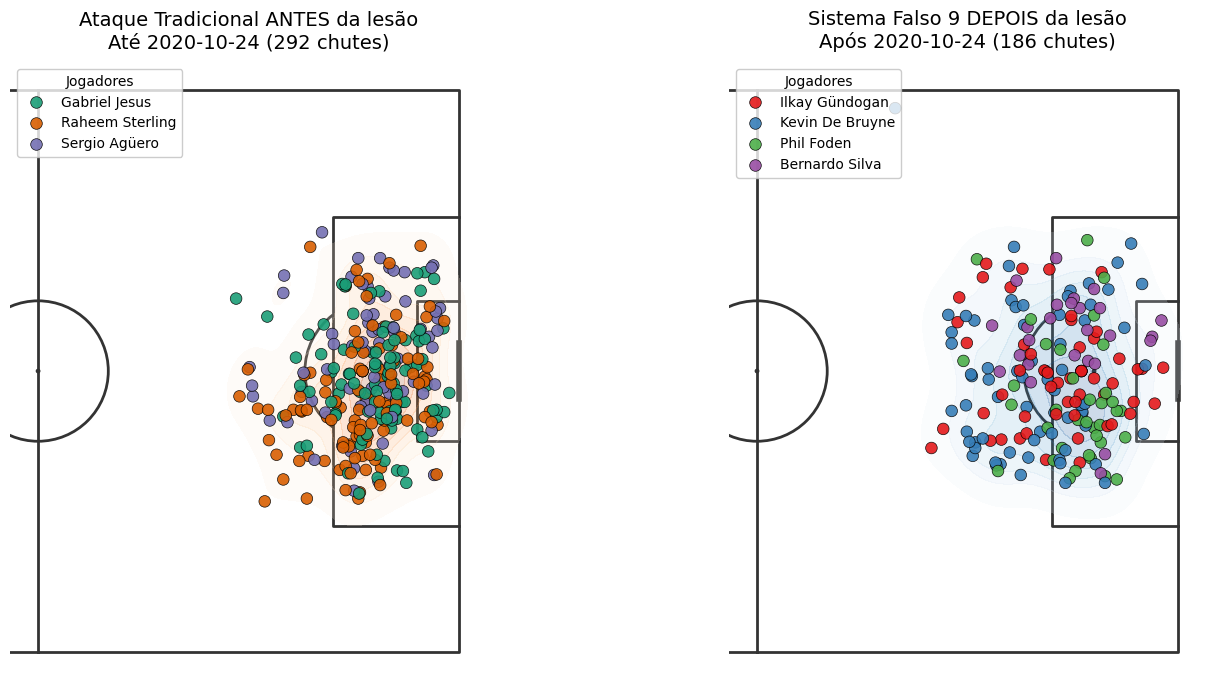

In [128]:

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')

# =========================================================
# PLOT 1: Sistema Tradicional (ANTES de 24/10/2020)
# =========================================================
# Verificando se há dados suficientes para não quebrar a mancha de calor
if len(trad_shots_antes) > 2:
    sns.kdeplot(x=trad_shots_antes['x_sb'], y=trad_shots_antes['y_sb'], ax=ax[0],
                fill=True, cmap='Oranges', thresh=0.05, levels=8, alpha=0.2)

# Scatter plot separando cada jogador por cor
sns.scatterplot(data=trad_shots_antes, x='x_sb', y='y_sb', hue='player',
                palette='Dark2', s=70, edgecolor='black', linewidth=0.5,
                alpha=0.9, ax=ax[0])

ax[0].set_title(f'Ataque Tradicional ANTES da lesão\nAté {data_lesao} ({len(trad_shots_antes)} chutes)', fontsize=14, pad=10)
ax[0].legend(title='Jogadores', loc='upper left', frameon=True,
             facecolor='white', edgecolor='silver', fontsize=10)

# =========================================================
# PLOT 2: Sistema Falso 9 (DEPOIS de 24/10/2020)
# =========================================================
if len(falso9_shots_depois) > 2:
    sns.kdeplot(x=falso9_shots_depois['x_sb'], y=falso9_shots_depois['y_sb'], ax=ax[1],
                fill=True, cmap='Blues', thresh=0.05, levels=8, alpha=0.2)

# Scatter plot separando cada jogador por cor
sns.scatterplot(data=falso9_shots_depois, x='x_sb', y='y_sb', hue='player',
                palette='Set1', s=70, edgecolor='black', linewidth=0.5,
                alpha=0.9, ax=ax[1])

ax[1].set_title(f'Sistema Falso 9 DEPOIS da lesão\nApós {data_lesao} ({len(falso9_shots_depois)} chutes)', fontsize=14, pad=10)
ax[1].legend(title='Jogadores', loc='upper left', frameon=True,
             facecolor='white', edgecolor='silver', fontsize=10)

plt.tight_layout()
plt.show()

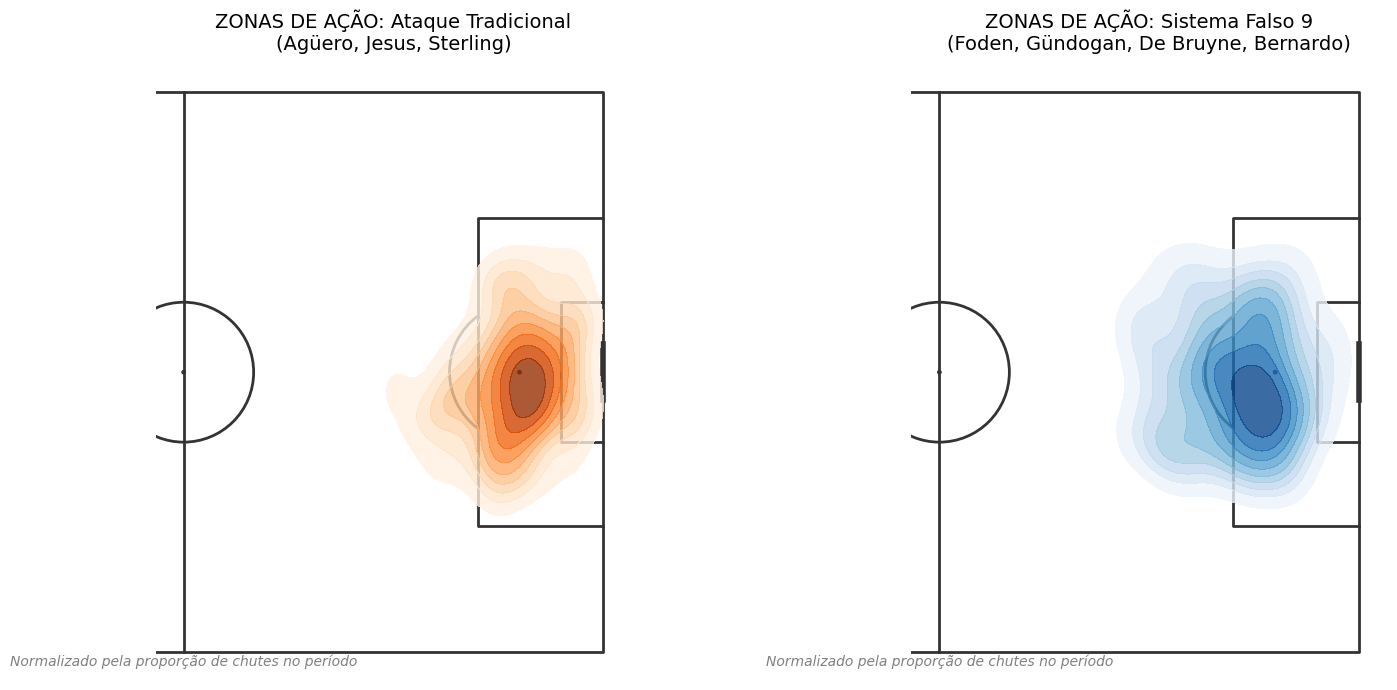

In [129]:
pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')

# =========================================================
# PLOT 1: Sistema Tradicional (Normalizado - Apenas KDE)
# =========================================================
if len(trad_shots_antes) > 2:
    # fill=True, thresh=0.1 (ignora os 10% mais raros para limpar bordas), alpha forte
    sns.kdeplot(x=trad_shots_antes['x_sb'], y=trad_shots_antes['y_sb'], ax=ax[0],
                fill=True, cmap='Oranges', thresh=0.1, levels=10, alpha=0.8)

ax[0].set_title(f'ZONAS DE AÇÃO: Ataque Tradicional\n(Agüero, Jesus, Sterling)', fontsize=14, pad=10)
# Subtítulo explicativo sobre a normalização
ax[0].text(60, 82, 'Normalizado pela proporção de chutes no período',
           fontsize=10, ha='center', color='gray', style='italic')

# =========================================================
# PLOT 2: Sistema Falso 9 (Normalizado - Apenas KDE)
# =========================================================
if len(falso9_shots_depois) > 2:
    sns.kdeplot(x=falso9_shots_depois['x_sb'], y=falso9_shots_depois['y_sb'], ax=ax[1],
                fill=True, cmap='Blues', thresh=0.1, levels=10, alpha=0.8)

ax[1].set_title(f'ZONAS DE AÇÃO: Sistema Falso 9\n(Foden, Gündogan, De Bruyne, Bernardo)', fontsize=14, pad=10)
ax[1].text(60, 82, 'Normalizado pela proporção de chutes no período',
           fontsize=10, ha='center', color='gray', style='italic')

plt.tight_layout()
plt.show()